## Insider Threat Radar – Behavior Analytics for Employee Risk Prediction

### Data Analysis & EDA 

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


#### Load Data

In [2]:
email_df = pd.read_csv("../Dataset/email.csv", low_memory=False)
psycho_df = pd.read_csv("../Dataset/psychometric.csv")

print("Datasets Loaded ✅")

Datasets Loaded ✅


#### Convert Date Column

In [3]:
email_df['date'] = pd.to_datetime(email_df['date'], errors='coerce')

print(email_df['date'].head())

0   2010-01-02 07:11:45
1   2010-01-02 07:12:16
2   2010-01-02 07:13:00
3   2010-01-02 07:13:17
4   2010-01-02 07:13:28
Name: date, dtype: datetime64[ns]


#### User-wise Email Count

In [4]:
user_activity = email_df['user'].value_counts()

print(user_activity.head(10))

user
MSS0001    12034
KBP0008     9145
HTH0007     9116
HCS0003     9097
KWC0004     8997
TVS0006     8994
BTW0005     8950
DLM0051     7573
ATE0869     7519
HPH0075     7435
Name: count, dtype: int64


#### Plot Heavy vs Light Users

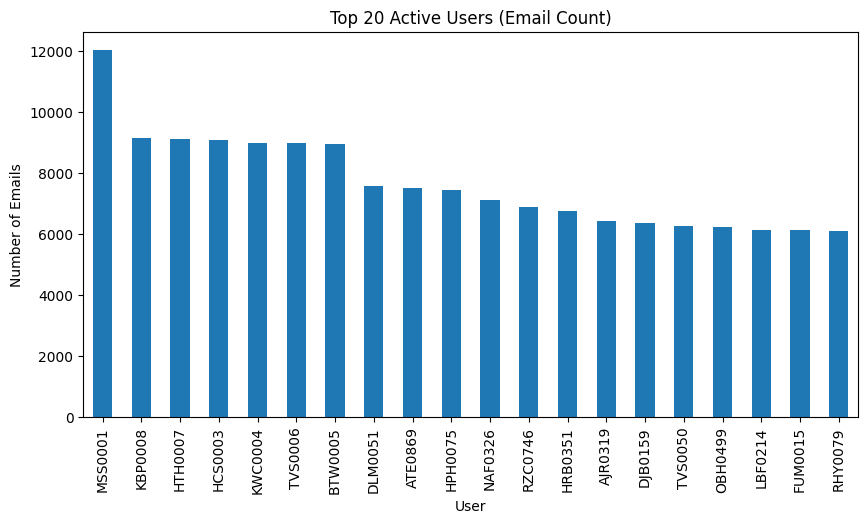

In [5]:
plt.figure(figsize=(10,5))
user_activity.head(20).plot(kind='bar')
plt.title("Top 20 Active Users (Email Count)")
plt.xlabel("User")
plt.ylabel("Number of Emails")
plt.show()

#### Hourly Activity Pattern

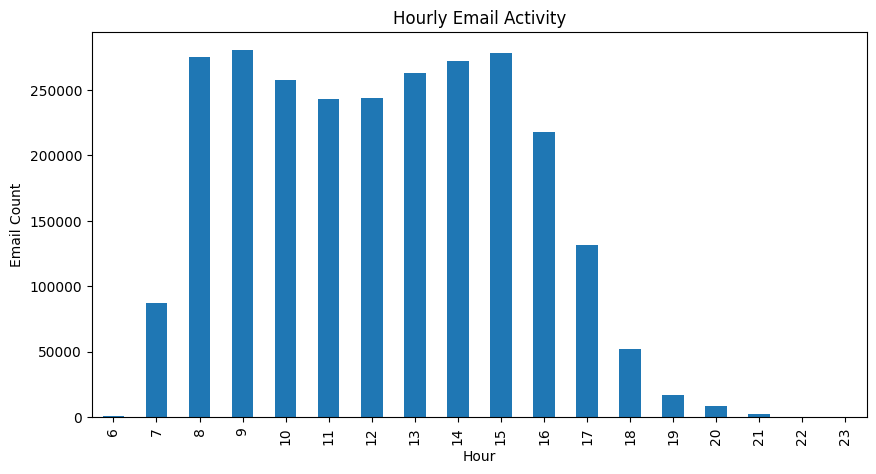

In [6]:
email_df['hour'] = email_df['date'].dt.hour

hourly = email_df['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hourly.plot(kind='bar')
plt.title("Hourly Email Activity")
plt.xlabel("Hour")
plt.ylabel("Email Count")
plt.show()

#### Day-wise Activity

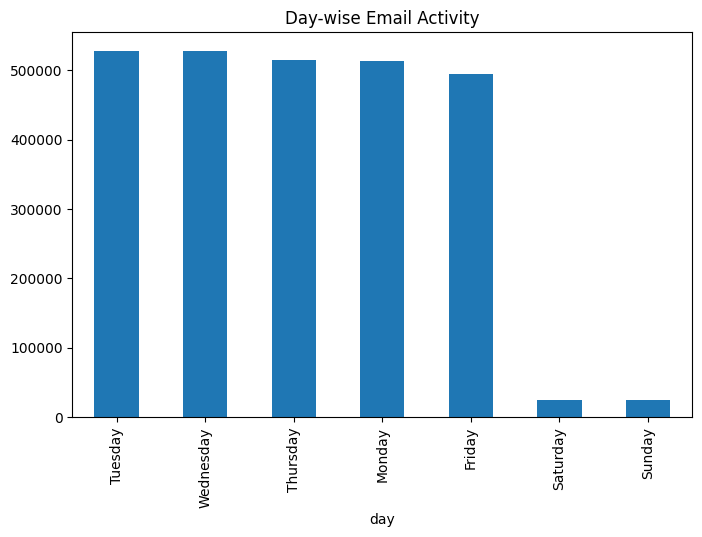

In [7]:
email_df['day'] = email_df['date'].dt.day_name()

day_activity = email_df['day'].value_counts()

plt.figure(figsize=(8,5))
day_activity.plot(kind='bar')
plt.title("Day-wise Email Activity")
plt.show()

#### Email Size Distribution

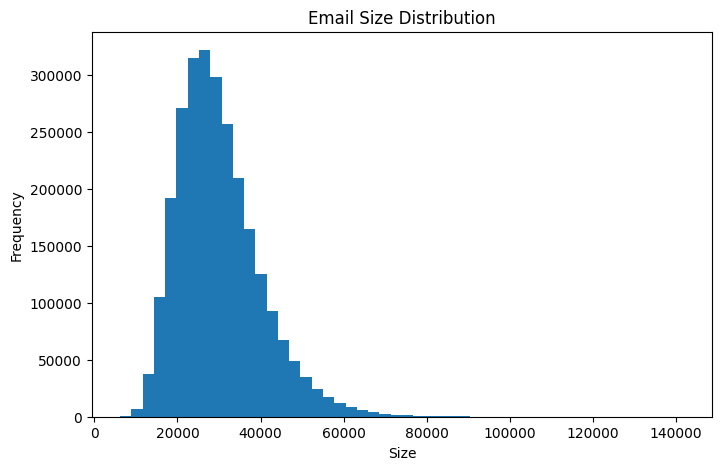

In [8]:
plt.figure(figsize=(8,5))
plt.hist(email_df['size'], bins=50)
plt.title("Email Size Distribution")
plt.xlabel("Size")
plt.ylabel("Frequency")
plt.show()

#### Attachment Analysis

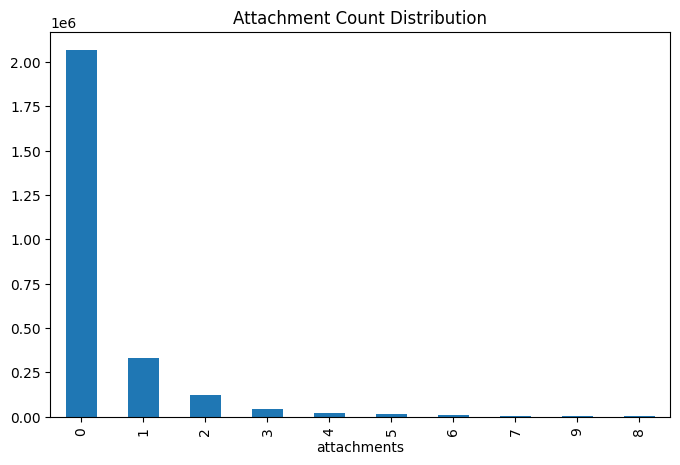

In [9]:
attach_count = email_df['attachments'].value_counts()

plt.figure(figsize=(8,5))
attach_count.plot(kind='bar')
plt.title("Attachment Count Distribution")
plt.show()

#### Merge Psychometric Data

In [10]:
merged_df = pd.merge(
    email_df,
    psycho_df,
    left_on='user',
    right_on='user_id',
    how='left'
)

print(merged_df.shape)
merged_df.head()

(2629979, 20)


,id,date,user,pc,to,cc,bcc,from,size,attachments,content,hour,day,employee_name,user_id,O,C,E,A,N
0,{R3I7-S4TX96FG-8219JWFF},2010-01-02 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...,7,Saturday,Lynn Adena Pratt,LAP0338,42,23,33,45,31
1,{R0R9-E4GL59IK-2907OSWJ},2010-01-02 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...,7,Saturday,Macaulay Otto Hopkins,MOH0273,39,40,47,50,26
2,{G2B2-A8XY58CP-2847ZJZL},2010-01-02 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...,7,Saturday,Lynn Adena Pratt,LAP0338,42,23,33,45,31
3,{A3A9-F4TH89AA-8318GFGK},2010-01-02 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...,7,Saturday,Lynn Adena Pratt,LAP0338,42,23,33,45,31
4,{E8B7-C8FZ88UF-2946RUQQ},2010-01-02 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...,7,Saturday,Macaulay Otto Hopkins,MOH0273,39,40,47,50,26


#### Personality vs Email Count

In [11]:
personality_activity = merged_df.groupby('user')[['O','C','E','A','N']].mean()

personality_activity.head()

,O,C,E,A,N
user,,,,,
AAE0190,36.0,30.0,14.0,50.0,29.0
AAF0535,17.0,21.0,36.0,33.0,31.0
AAF0791,14.0,40.0,40.0,50.0,34.0
AAL0706,37.0,14.0,28.0,13.0,25.0
AAM0658,43.0,35.0,37.0,36.0,22.0


#### Correlation Heatmap

**Personality**

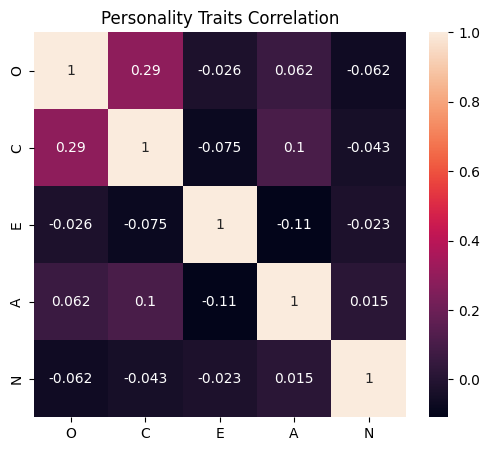

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(personality_activity.corr(), annot=True)
plt.title("Personality Traits Correlation")
plt.show()